# 1D Manning's N Calibration Workflow

Demonstrates automated Manning's n calibration for a 1D HEC-RAS unsteady model
using the `RasCalibrate` module with `grid_search()` and `optimize()`.

## Two Examples

| Example | Method | Project | Parameters |
|---------|--------|---------|------------|
| 1 | Grid search | Example 24 - Mannings-n-Calibration | Channel n multipliers (Upper Miss + Lower Miss) |
| 2 | Optimization (Nelder-Mead) | Example 24 - Mannings-n-Calibration | Channel n multipliers (combined) |

## Calibration Approach

This notebook uses a **synthetic observed data** approach:

1. Run the model with original Manning's n to generate "truth" water surface elevations
2. Define `CalibrationPoint` objects at representative cross sections using those WSE as observations
3. Perturb Manning's n and run `grid_search()` to recover the original values
4. Run `optimize()` for a continuous Nelder-Mead search

This workflow mirrors real calibration except that observed data comes from streamflow
gauges or survey data instead of a model run.

## Background

The project is the **Mississippi-Ohio River junction** model from the HEC-RAS Example Applications
Guide (Example 24 - Manning's n Calibration). It includes:
- Mississippi River: Upper Miss and Lower Miss reaches (394 cross sections)
- Ohio River: OHS reach
- Unsteady simulation (~5.5 months, Sep 2004 to Mar 2005)
- Built-in HEC-RAS calibration zones defined as `Roughness Change` multipliers per reach segment

## Prerequisites

- HEC-RAS 6.x installed (version 6.6 recommended)
- `ras-commander` installed (`pip install ras-commander` or editable install)
- Sufficient disk space (~500 MB) and compute time (~5 min per simulation)

> **Note**: The grid search runs 3 simulations; the optimizer runs up to ~10 iterations.
> Total runtime: 20-60 minutes depending on your hardware.

In [1]:
# Standard library imports
from pathlib import Path
import re
import sys
import warnings

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# Flexible imports: works with installed package or editable install
try:
    from ras_commander import (
        init_ras_project,
        RasCmdr,
        RasExamples,
        RasPlan,
        RasCalibrate,
        CalibrationPoint,
    )
    from ras_commander.hdf import HdfResultsXsec
except ImportError:
    current_file = Path(".").resolve()
    parent_directory = current_file.parent
    sys.path.insert(0, str(parent_directory))
    from ras_commander import (
        init_ras_project,
        RasCmdr,
        RasExamples,
        RasPlan,
        RasCalibrate,
        CalibrationPoint,
    )
    from ras_commander.hdf import HdfResultsXsec

print("Imports successful.")

Imports successful.


---
## Setup: Extract and Initialize Project

In [2]:
# Extract and initialize Example 24 - Manning's n Calibration
project_path = RasExamples.extract_project(
    "Example 24 - Mannings-n-Calibration",
    suffix="calib_1d",
)
ras = init_ras_project(project_path, "6.6")

print(f"Project folder: {project_path}")
print()
print("Plans:")
display(
    ras.plan_df[
        ["plan_number", "Plan Title", "Short Identifier", "Simulation Date"]
    ]
)
print()
print("Geometry:")
display(
    ras.geom_df[
        ["geom_number", "geom_title", "num_cross_sections", "has_1d_xs"]
    ]
)

2026-04-12 13:30:23 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\bill\AppData\Local\ras-commander\examples\Example_Projects_6_6.zip


2026-04-12 13:30:23 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-04-12 13:30:23 - ras_commander.RasExamples - INFO - Loaded 68 projects from CSV.


2026-04-12 13:30:23 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-12 13:30:23 - ras_commander.RasExamples - INFO - Extracting project 'Example 24 - Mannings-n-Calibration' as 'Example 24 - Mannings-n-Calibration_calib_1d'


...

2026-04-12 13:30:24 - ras_commander.RasPrj - INFO - Project initialized: Manning'snCalibra | Folder: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d


Project folder: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d

Plans:


,plan_number,Plan Title,Short Identifier,Simulation Date
0,01,Automatic Calibration,AutoCalibrate,"25sep2004,12:00,05MAR2005,12:00"
1,02,No Calibration Run,NoCalibration,"25sep2004,12:00,05MAR2005,12:00"
2,03,Automatic Calibration - Squared Error,Cal-SqErr,"25sep2004,12:00,05MAR2005,12:00"
3,04,Automatic Calibration - Sequential,AutoCalSequentia,"25sep2004,12:00,05MAR2005,12:00"
4,05,Automatic Calibration - Final Model,Final Model,"25sep2004,12:00,05MAR2005,12:00"



Geometry:


,geom_number,geom_title,num_cross_sections,has_1d_xs
0,01,Mississippi Ohio Junction,394,True


---
## Step 1: Run Baseline Simulation to Generate "Truth" WSE

We use **Plan 02 (No Calibration Run)** as the baseline. It applies a global
Manning's n multiplier of 1.0 (no change from geometry defaults) to all reaches.
The resulting water surface elevations become our synthetic observations.

In [3]:
# Run plan 02 (No Calibration Run) with default n values
# This generates the 'truth' results we will calibrate against
print("Running baseline plan 02 (No Calibration Run)...")
print("Expected runtime: ~5-15 minutes depending on hardware.")

RasCmdr.compute_plan(
    "02",
    ras_object=ras,
    force_rerun=False,   # Smart skip if already current
    num_cores=2,
)

# Verify results
hdf_path_str = ras.plan_df.loc[
    ras.plan_df["plan_number"] == "02", "HDF_Results_Path"
].iloc[0]

if hdf_path_str and Path(hdf_path_str).exists():
    print(f"Baseline HDF: {hdf_path_str}")
else:
    raise RuntimeError("Plan 02 did not produce an HDF file. Check HEC-RAS installation.")

2026-04-12 13:30:24 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d


2026-04-12 13:30:24 - ras_commander.RasUtils - INFO - Using provided plan file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02


2026-04-12 13:30:24 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02


Running baseline plan 02 (No Calibration Run)...
Expected runtime: ~5-15 minutes depending on hardware.


2026-04-12 13:30:24 - ras_commander.RasCmdr - INFO - Set number of cores to 2 for plan: 02


...

2026-04-12 13:32:03 - ras_commander.hdf.HdfResultsPlan - INFO - Simulation Duration (hours): 3864.0


2026-04-12 13:32:03 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 13:32:03 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 13:32:03 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Baseline HDF: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


---
## Step 2: Extract Baseline WSE at Representative Cross Sections

We extract the peak (maximum over time) water surface elevation at select cross
sections along each calibration reach. These become our synthetic observations.

In [4]:
# Extract cross-section timeseries from baseline run
baseline_hdf = Path(hdf_path_str)
ds = HdfResultsXsec.get_xsec_timeseries(baseline_hdf)

print("Timeseries dataset variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
print()

# Show coordinate dimensions
rivers = [str(v).strip() for v in ds.coords["River"].values]
reaches = [str(v).strip() for v in ds.coords["Reach"].values]
stations = [str(v).strip() for v in ds.coords["Station"].values]

xs_info = pd.DataFrame(
    {"River": rivers, "Reach": reaches, "Station": stations}
)
print(f"Total cross sections with output: {len(xs_info)}")
print()
print("Reach summary:")
print(xs_info.groupby(["River", "Reach"]).size().rename("XS count"))

2026-04-12 13:32:03 - ras_commander.hdf.HdfResultsXsec - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 13:32:03 - ras_commander.hdf.HdfResultsXsec - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


Timeseries dataset variables: ['Water_Surface', 'Velocity_Total', 'Velocity_Channel', 'Flow_Lateral', 'Flow']
Coordinates: ['time', 'cross_section', 'River', 'Reach', 'Station', 'Name', 'Maximum_Water_Surface', 'Maximum_Flow', 'Maximum_Channel_Velocity', 'Maximum_Velocity_Total', 'Maximum_Flow_Lateral']

Total cross sections with output: 394

Reach summary:
River        Reach      
Mississippi  Lower Miss.    110
             Upper Miss     230
Ohio River   OHS             54
Name: XS count, dtype: int64


In [5]:
# Extract peak WSE (maximum over simulation period) for each cross section
# Note: HEC-RAS HDF stores the variable as "Water_Surface" (with underscore)
wse_data = ds["Water_Surface"]         # shape: (n_xs, n_timesteps)
peak_wse = wse_data.max(dim="time")    # shape: (n_xs,)

peak_wse_df = pd.DataFrame(
    {
        "River": rivers,
        "Reach": reaches,
        "Station": stations,
        "peak_wse_ft": peak_wse.values,
    }
)

print("Peak WSE summary by reach:")
display(
    peak_wse_df.groupby(["River", "Reach"])["peak_wse_ft"]
    .agg(["min", "mean", "max", "count"])
    .round(2)
)

# Select representative cross sections: a few per calibration reach
# Upper Miss: 3 stations spanning the reach
# Lower Miss: 3 stations spanning the reach
upper_miss_xs = (
    peak_wse_df[peak_wse_df["Reach"] == "Upper Miss"]
    .dropna(subset=["peak_wse_ft"])
    .iloc[[10, 60, 120]]   # sample early, mid, late in reach
)
lower_miss_xs = (
    peak_wse_df[peak_wse_df["Reach"] == "Lower Miss."]
    .dropna(subset=["peak_wse_ft"])
    .iloc[[5, 30, 60]]
)

selected_xs = pd.concat([upper_miss_xs, lower_miss_xs], ignore_index=True)
print()
print("Selected calibration cross sections:")
display(selected_xs[["River", "Reach", "Station", "peak_wse_ft"]].round(3))

Peak WSE summary by reach:


min        mean         max  count
River       Reach                                                 
Mississippi Lower Miss.  270.309998  299.630005  323.309998    110
            Upper Miss   323.309998  342.010010  368.890015    230
Ohio River  OHS          323.309998  326.820007  330.549988     54


Selected calibration cross sections:


,River,Reach,Station,peak_wse_ft
0,Mississippi,Upper Miss,107.3,367.321014
1,Mississippi,Upper Miss,81.09,354.108002
2,Mississippi,Upper Miss,51.03,338.936005
3,Mississippi,Lower Miss.,950,321.622986
4,Mississippi,Lower Miss.,925,313.428986
5,Mississippi,Lower Miss.,895,298.157013


---
## Step 3: Inspect Manning's n Zones

The plan file stores Manning's n calibration zones as `Roughness Change` lines.
Each zone applies a multiplier (1.0 = no change) to the base geometry values
for a reach segment defined by upstream/downstream river stations.

We will calibrate a single **global channel multiplier** applied uniformly to
all zones. In practice, you would calibrate zone-specific multipliers.

In [6]:
def parse_roughness_zones(plan_path: Path) -> list:
    """Parse Roughness Change zones from a HEC-RAS plan file.

    Returns a list of dicts with keys: river, reach, us_station, ds_station,
    header_line_idx, multiplier_line_indices.
    """
    lines = plan_path.read_text(encoding="utf-8", errors="replace").splitlines()
    zones = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("Roughness Change="):
            parts = line.split("=", 1)[1].split(",")
            if len(parts) >= 5:
                river = parts[0].strip()
                reach = parts[1].strip()
                us_sta = parts[2].strip()
                ds_sta = parts[3].strip()
                n_entries = int(parts[4].strip())
                # Each data line holds ~5 pairs; ceil(n_entries / 5) lines
                n_data_lines = (n_entries + 4) // 5
                zones.append(
                    {
                        "river": river,
                        "reach": reach,
                        "us_station": us_sta,
                        "ds_station": ds_sta,
                        "n_entries": n_entries,
                        "header_line_idx": i,
                        "multiplier_line_indices": list(
                            range(i + 1, i + 1 + n_data_lines)
                        ),
                    }
                )
        i += 1
    return zones


# Inspect baseline plan zones
plan02_path = ras.plan_df.loc[
    ras.plan_df["plan_number"] == "02", "full_path"
].iloc[0]
baseline_zones = parse_roughness_zones(Path(plan02_path))

print(f"Plan 02 has {len(baseline_zones)} Roughness Change zones:")
for z in baseline_zones:
    print(
        f"  {z['river']}/{z['reach']} "
        f"sta {z['us_station']} -> {z['ds_station']}  "
        f"({z['n_entries']} multipliers)"
    )

Plan 02 has 6 Roughness Change zones:
  Mississippi/Upper Miss sta 43.7 -> 29.09  (14 multipliers)
  Mississippi/Lower Miss. sta 953.5 -> 923  (13 multipliers)
  Mississippi/Lower Miss. sta 922 -> 874  (16 multipliers)
  Mississippi/Lower Miss. sta 873 -> 846  (24 multipliers)
  Mississippi/Upper Miss sta 110.4 -> 43.702  (14 multipliers)
  Mississippi/Upper Miss sta 28.57 -> 1.39  (14 multipliers)


---
## Step 4: Define the Apply Function for 1D Manning's n

The `apply_fn` receives `(plan_path, param_row, ras_object)` and modifies the
cloned plan file before HEC-RAS executes it. For this 1D model, we modify the
`Roughness Change` multipliers directly in the plan file.

- `n_upper_miss_mult`: multiplier for Upper Mississippi reach zones
- `n_lower_miss_mult`: multiplier for Lower Mississippi reach zones

In [7]:
def _rebuild_multiplier_lines(n_entries: int, multiplier: float) -> list:
    """Rebuild data lines for a Roughness Change zone with a new multiplier.

    HEC-RAS format: up to 5 (station, multiplier) pairs per line.
    Stations are sequential 1-based integers scaled by 100000.
    The multiplier is a float rounded to 4 decimal places.
    """
    pairs = []
    for k in range(n_entries):
        station_val = (k + 1) * 100000
        pairs.append((station_val, round(multiplier, 6)))

    new_lines = []
    for chunk_start in range(0, len(pairs), 5):
        chunk = pairs[chunk_start : chunk_start + 5]
        line_parts = "".join(
            f"{sta:8d}{mult:8.4f}" for sta, mult in chunk
        )
        new_lines.append(line_parts)
    return new_lines


def make_1d_roughness_apply_fn(
    param_to_reach_map: dict,
) -> object:
    """Factory for a 1D Manning's n apply_fn that modifies Roughness Change multipliers.

    Args:
        param_to_reach_map: Maps parameter column name to reach name substring.
            Example: {'n_upper_mult': 'Upper Miss', 'n_lower_mult': 'Lower Miss.'}
            A parameter value of 1.0 means 100% of baseline n (no change).

    Returns:
        An apply_fn compatible with RasCalibrate.grid_search() and optimize().
    """

    def apply_fn(plan_path, param_row, ras_object=None):
        plan_path = Path(plan_path)
        lines = plan_path.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()

        zones = parse_roughness_zones(plan_path)

        # Build reach -> multiplier lookup from param_row
        reach_multiplier = {}
        for param_col, reach_substr in param_to_reach_map.items():
            if param_col in param_row.index:
                reach_multiplier[reach_substr] = float(param_row[param_col])

        # Apply multipliers to matching zones
        modified_lines = lines.copy()
        for zone in zones:
            for reach_substr, mult in reach_multiplier.items():
                if reach_substr in zone["reach"]:
                    new_data = _rebuild_multiplier_lines(
                        zone["n_entries"], mult
                    )
                    for line_idx, new_line in zip(
                        zone["multiplier_line_indices"], new_data
                    ):
                        modified_lines[line_idx] = new_line

        plan_path.write_text(
            "\n".join(modified_lines) + "\n",
            encoding="utf-8",
        )

    return apply_fn


# Test the apply function on plan 02 at baseline (multiplier = 1.0)
test_apply_fn = make_1d_roughness_apply_fn(
    {
        "n_upper_mult": "Upper Miss",
        "n_lower_mult": "Lower Miss.",
    }
)

test_params = pd.Series({"n_upper_mult": 1.0, "n_lower_mult": 1.0})
test_apply_fn(plan02_path, test_params)

# Verify zones parse correctly after apply
zones_after = parse_roughness_zones(Path(plan02_path))
print(f"Verified: {len(zones_after)} zones found after apply_fn test.")
print("Apply function factory working correctly.")

Verified: 6 zones found after apply_fn test.
Apply function factory working correctly.


---
## Step 5: Define Calibration Points

Each `CalibrationPoint` specifies:
- `extraction_method="1d_xs"`: extract from 1D cross section timeseries
- `river`, `reach`, `station`: must match the HEC-RAS cross section identifiers exactly
- `observed`: the peak WSE from the baseline run (our synthetic truth)
- `time_index="max"`: extract the simulation maximum (matching how we got the truth)
- `metric`: objective for this point (RMSE - lower is better for scalar targets)

In [8]:
# Build calibration points from selected cross sections
calibration_points = []
for _, row in selected_xs.iterrows():
    cp = CalibrationPoint(
        name=f"{row['Reach'].replace(' ', '_').replace('.', '')}_{row['Station']}",
        variable="wse",
        extraction_method="1d_xs",
        observed=float(row["peak_wse_ft"]),
        river=row["River"],
        reach=row["Reach"],
        station=row["Station"],
        time_index="max",
        metric="rmse",
        weight=1.0,
    )
    calibration_points.append(cp)

print(f"Created {len(calibration_points)} calibration points:")
for cp in calibration_points:
    print(
        f"  {cp.name}: {cp.river}/{cp.reach} sta {cp.station}, "
        f"observed WSE = {cp.observed:.2f} ft"
    )

Created 6 calibration points:
  Upper_Miss_107.3: Mississippi/Upper Miss sta 107.3, observed WSE = 367.32 ft
  Upper_Miss_81.09: Mississippi/Upper Miss sta 81.09, observed WSE = 354.11 ft
  Upper_Miss_51.03: Mississippi/Upper Miss sta 51.03, observed WSE = 338.94 ft
  Lower_Miss_950: Mississippi/Lower Miss. sta 950, observed WSE = 321.62 ft
  Lower_Miss_925: Mississippi/Lower Miss. sta 925, observed WSE = 313.43 ft
  Lower_Miss_895: Mississippi/Lower Miss. sta 895, observed WSE = 298.16 ft


---
## Example 1: Grid Search Calibration

We search over a grid of Manning's n multipliers for Upper Miss and Lower Miss
reaches. The "truth" is multiplier = 1.0. We search from 0.8 to 1.2 in 3 steps
to keep runtime short (3 × 3 = 9 combinations, but we do a focused 3-point search
per reach = 3 simulations total via `grid_search` with one varied parameter at a time).

> **Runtime**: Each grid_search point runs one HEC-RAS simulation (~5-15 min each).

In [9]:
# Create apply_fn for grid search
grid_apply_fn = make_1d_roughness_apply_fn(
    {
        "n_upper_mult": "Upper Miss",
        "n_lower_mult": "Lower Miss.",
    }
)

# Define parameter grid: 3 values per parameter
# Truth is 1.0; we search 0.85 to 1.15 to verify recovery
parameters = {
    "n_upper_mult": [0.85, 1.0, 1.15],
    "n_lower_mult": [0.85, 1.0, 1.15],
}

print("Grid search parameters:")
from ras_commander import RasPermutation
params_preview = RasPermutation.define_parameters(parameters)
print(f"Total simulations: {len(params_preview)}")
display(params_preview[["absolute_perm_id", "n_upper_mult", "n_lower_mult"]])

2026-04-12 13:32:04 - ras_commander.RasPermutation - INFO - Defined 9 total permutation(s)


Grid search parameters:
Total simulations: 9


,absolute_perm_id,n_upper_mult,n_lower_mult
0,1,0.85,0.85
1,2,0.85,1.00
2,3,0.85,1.15
3,4,1.00,0.85
4,5,1.00,1.00
5,6,1.00,1.15
6,7,1.15,0.85
7,8,1.15,1.00
8,9,1.15,1.15


In [10]:
print("Running grid search...")
print(f"This will run {len(params_preview)} HEC-RAS simulations in parallel.")
print("Expected runtime: 30-90 minutes depending on hardware.")
print()

grid_results = RasCalibrate.grid_search(
    template_plan="02",         # No Calibration Run (base multipliers = 1.0)
    parameters=parameters,
    apply_fn=grid_apply_fn,
    calibration_points=calibration_points,
    metric="rmse",              # RMSE between observed and modeled peak WSE
    suffix="gs1d",
    max_workers=2,              # Run 2 simulations at a time
    num_cores=2,
    ras_object=ras,
)

print()
print(f"Grid search complete. {len(grid_results)} results returned.")
print()
print("Grid search results (sorted by overall RMSE):")
display_cols = [
    "n_upper_mult",
    "n_lower_mult",
    "overall_objective",
    "n_points_scored",
    "status",
]
display(grid_results[display_cols].round(4))

2026-04-12 13:32:04 - ras_commander.RasPermutation - INFO - Defined 9 total permutation(s)


Running grid search...
This will run 9 HEC-RAS simulations in parallel.
Expected runtime: 30-90 minutes depending on hardware.



2026-04-12 13:32:04 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d_gs1d_001\Manning'snCalibra.rasmap


2026-04-12 13:32:04 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d_gs1d_001


2026-04-12 13:32:04 - ras_commander.RasPrj - INFO - ras-commander v0.91.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


...

2026-04-12 13:40:44 - ras_commander.hdf.HdfResultsXsec - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d_gs1d_001\Manning'snCalibra.p14.hdf


2026-04-12 13:40:44 - ras_commander.hdf.HdfResultsXsec - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d_gs1d_001\Manning'snCalibra.p14.hdf


2026-04-12 13:40:44 - ras_commander.hdf.HdfResultsXsec - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d_gs1d_001\Manning'snCalibra.p14.hdf



Grid search complete. 9 results returned.

Grid search results (sorted by overall RMSE):


,n_upper_mult,n_lower_mult,overall_objective,n_points_scored,status
0,1.00,1.00,0.0000,6,completed
1,1.15,1.00,1.2951,6,completed
2,0.85,1.00,1.4042,6,completed
3,1.00,1.15,1.8948,6,completed
4,1.00,0.85,1.9044,6,completed
5,0.85,1.15,2.9553,6,completed
6,1.15,1.15,3.1258,6,completed
7,1.15,0.85,3.1346,6,completed
8,0.85,0.85,3.3265,6,completed


In [11]:
# Identify the best parameter combination
best_row = grid_results.iloc[0]
best_upper = best_row["n_upper_mult"]
best_lower = best_row["n_lower_mult"]
best_rmse = best_row["overall_objective"]

print("Best grid search result:")
print(f"  Upper Miss multiplier: {best_upper:.4f}  (truth = 1.0)")
print(f"  Lower Miss multiplier: {best_lower:.4f}  (truth = 1.0)")
print(f"  Overall RMSE: {best_rmse:.4f} ft")
print()

# Show per-point objectives if available
point_cols = [c for c in grid_results.columns if "_objective" in c and c != "overall_objective"]
if point_cols:
    print("Per-point RMSE at best parameter set:")
    for col in point_cols:
        val = grid_results.iloc[0][col]
        name = col.replace("_objective", "").replace("point_", "")
        print(f"  {name}: {val:.4f} ft")

Best grid search result:
  Upper Miss multiplier: 1.0000  (truth = 1.0)
  Lower Miss multiplier: 1.0000  (truth = 1.0)
  Overall RMSE: 0.0000 ft

Per-point RMSE at best parameter set:
  01_upper_miss_107_3: 0.0000 ft
  02_upper_miss_81_09: 0.0000 ft
  03_upper_miss_51_03: 0.0000 ft
  04_lower_miss_950: 0.0000 ft
  05_lower_miss_925: 0.0000 ft
  06_lower_miss_895: 0.0000 ft


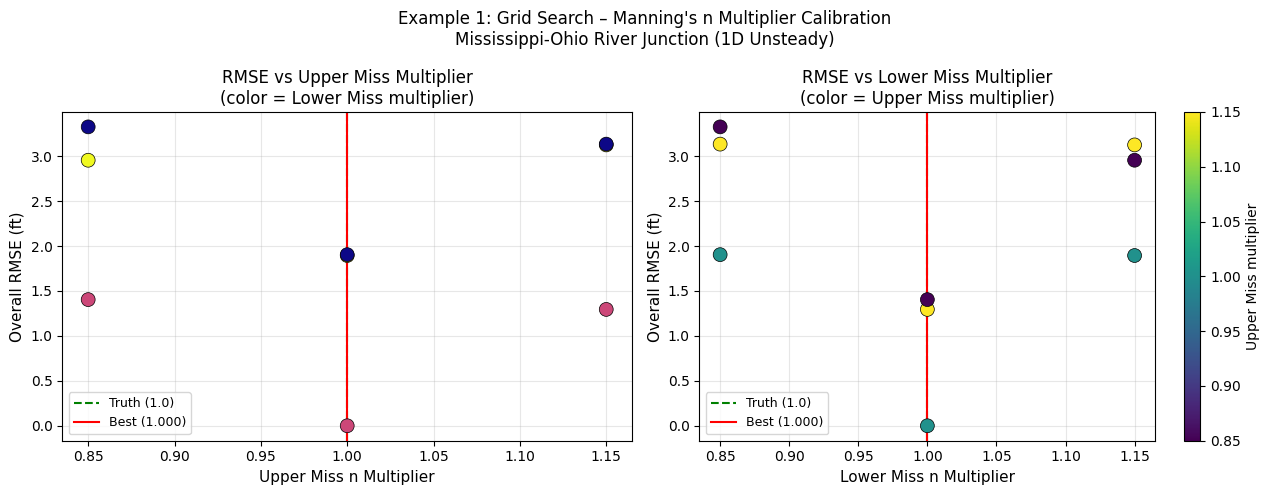


Interpretation: The green dashed line marks the true multiplier (1.0).
  The red solid line shows the best grid point found by the search.
  Lower RMSE = better agreement with baseline WSE.


In [12]:
# Visualize grid search results
if {"n_upper_mult", "n_lower_mult"}.issubset(grid_results.columns):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Example 1: Grid Search – Manning's n Multiplier Calibration\n"
        "Mississippi-Ohio River Junction (1D Unsteady)",
        fontsize=12,
    )

    # Left: RMSE vs Upper Miss multiplier
    ax = axes[0]
    ax.scatter(
        grid_results["n_upper_mult"],
        grid_results["overall_objective"],
        c=grid_results["n_lower_mult"],
        cmap="plasma",
        s=100,
        edgecolors="k",
        linewidths=0.5,
        zorder=3,
    )
    ax.axvline(1.0, color="green", linestyle="--", label="Truth (1.0)")
    ax.axvline(best_upper, color="red", linestyle="-", label=f"Best ({best_upper:.3f})")
    ax.set_xlabel("Upper Miss n Multiplier", fontsize=11)
    ax.set_ylabel("Overall RMSE (ft)", fontsize=11)
    ax.set_title("RMSE vs Upper Miss Multiplier\n(color = Lower Miss multiplier)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Right: RMSE vs Lower Miss multiplier
    ax = axes[1]
    sc = ax.scatter(
        grid_results["n_lower_mult"],
        grid_results["overall_objective"],
        c=grid_results["n_upper_mult"],
        cmap="viridis",
        s=100,
        edgecolors="k",
        linewidths=0.5,
        zorder=3,
    )
    plt.colorbar(sc, ax=ax, label="Upper Miss multiplier")
    ax.axvline(1.0, color="green", linestyle="--", label="Truth (1.0)")
    ax.axvline(best_lower, color="red", linestyle="-", label=f"Best ({best_lower:.3f})")
    ax.set_xlabel("Lower Miss n Multiplier", fontsize=11)
    ax.set_ylabel("Overall RMSE (ft)", fontsize=11)
    ax.set_title("RMSE vs Lower Miss Multiplier\n(color = Upper Miss multiplier)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print()
    print("Interpretation: The green dashed line marks the true multiplier (1.0).")
    print("  The red solid line shows the best grid point found by the search.")
    print("  Lower RMSE = better agreement with baseline WSE.")

---
## Example 2: Optimization with Nelder-Mead

Instead of exhaustive search, `RasCalibrate.optimize()` uses SciPy's Nelder-Mead
algorithm to find the best parameter combination iteratively. It modifies and
re-runs the same plan in place, evaluating the objective at each step.

For this example we calibrate a **single combined multiplier** applied equally to
both reaches, simplifying the search space to 1D and keeping runtime manageable.

> **Runtime**: Each optimizer iteration = one HEC-RAS run. With `max_iterations=8`
> this runs ~10 simulations total.

In [13]:
# For optimization, use a single global multiplier applied to both reaches.
# This simplifies the search to 1 dimension.

opt_apply_fn = make_1d_roughness_apply_fn(
    {
        "n_global_mult": "Upper Miss",  # applied to Upper Miss zones
        # Lower Miss gets same value via second entry
    }
)

# Actually apply global to both reaches
def global_apply_fn(plan_path, param_row, ras_object=None):
    """Apply a single n_global_mult to all Roughness Change zones."""
    plan_path = Path(plan_path)
    lines = plan_path.read_text(encoding="utf-8", errors="replace").splitlines()
    zones = parse_roughness_zones(plan_path)
    multiplier = float(param_row["n_global_mult"])
    modified_lines = lines.copy()
    for zone in zones:
        new_data = _rebuild_multiplier_lines(zone["n_entries"], multiplier)
        for line_idx, new_line in zip(zone["multiplier_line_indices"], new_data):
            modified_lines[line_idx] = new_line
    plan_path.write_text(
        "\n".join(modified_lines) + "\n",
        encoding="utf-8",
    )


print("Optimizer setup:")
print("  Parameter: n_global_mult (applied to all Roughness Change zones)")
print("  Bounds: [0.8, 1.2]")
print("  Algorithm: Nelder-Mead")
print("  Max iterations: 8")
print("  Metric: RMSE")
print()
print("Running optimization...")
print("Expected runtime: 60-120 minutes (each iteration = 1 HEC-RAS run).")

opt_result = RasCalibrate.optimize(
    plan_number="02",
    parameter_bounds={"n_global_mult": (0.8, 1.2)},
    apply_fn=global_apply_fn,
    calibration_points=calibration_points,
    metric="rmse",
    method="nelder-mead",
    max_iterations=8,
    num_cores=2,
    ras_object=ras,
)

print()
print("Optimization complete.")
print(f"  Success: {opt_result['success']}")
print(f"  Message: {opt_result['message']}")
print(f"  Iterations: {opt_result['nit']}")
print(f"  Function evaluations: {opt_result['nfev']}")
print()
print(f"  Starting n_global_mult: {opt_result['starting_parameters']['n_global_mult']:.4f}")
print(f"  Best n_global_mult:     {opt_result['best_parameters']['n_global_mult']:.4f}  (truth = 1.0)")
print(f"  Best overall RMSE:      {opt_result['best_objective']:.4f} ft")

2026-04-12 13:40:45 - ras_commander.RasCalibrate - WARNING - SciPy's Nelder-Mead bound handling varies by version; midpoint initialization stays inside the requested bounds, but strict bound enforcement depends on SciPy.


2026-04-12 13:40:45 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d


2026-04-12 13:40:45 - ras_commander.RasUtils - INFO - Using provided plan file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02


2026-04-12 13:40:45 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02


2026-04-12 13:40:45 - ras_commander.RasCmdr - INFO - Set number of cores to 2 for plan: 02


...

2026-04-12 14:06:58 - ras_commander.hdf.HdfResultsXsec - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 14:06:58 - ras_commander.hdf.HdfResultsXsec - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 14:06:58 - ras_commander.hdf.HdfResultsXsec - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf


2026-04-12 14:06:58 - ras_commander.hdf.HdfResultsXsec - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\Example 24 - Mannings-n-Calibration_calib_1d\Manning'snCalibra.p02.hdf



Optimization complete.
  Success: False
  Message: Maximum number of iterations has been exceeded.
  Iterations: 8
  Function evaluations: 16

  Starting n_global_mult: 1.0000
  Best n_global_mult:     1.0000  (truth = 1.0)
  Best overall RMSE:      0.0000 ft


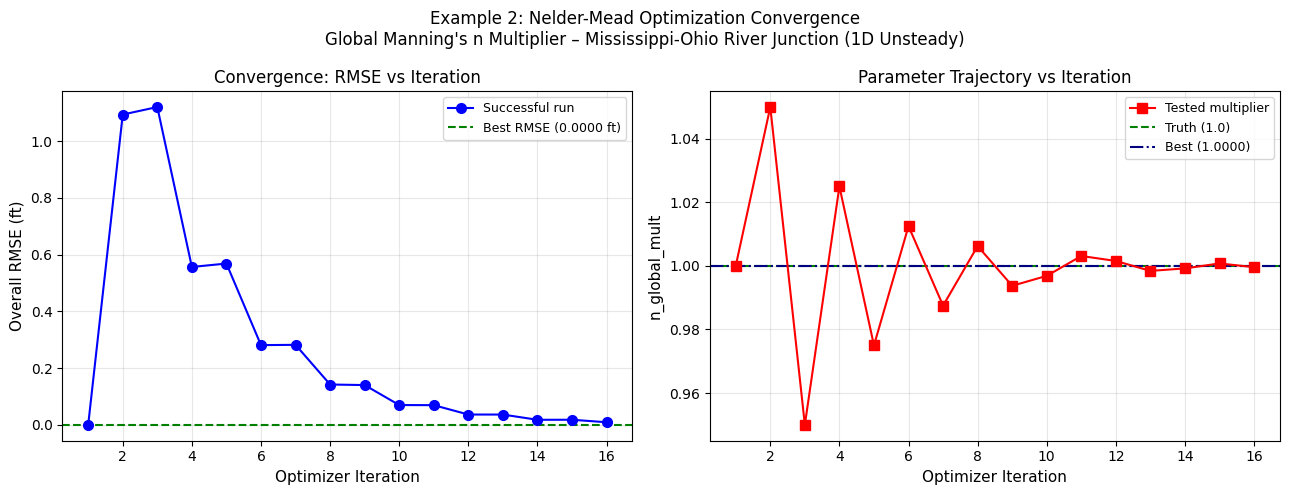


Interpretation:
  Top chart: RMSE should decrease as the optimizer converges.
  Bottom chart: The parameter should approach the truth (1.0).


In [14]:
# Plot optimization convergence
history_df = opt_result["iteration_history"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Example 2: Nelder-Mead Optimization Convergence\n"
    "Global Manning's n Multiplier – Mississippi-Ohio River Junction (1D Unsteady)",
    fontsize=12,
)

# Left: RMSE by iteration
ax = axes[0]
valid_mask = history_df["raw_objective"].notna() & history_df["success"]
iters = np.arange(1, len(history_df) + 1)

ax.plot(
    iters[valid_mask],
    history_df.loc[valid_mask, "raw_objective"],
    "bo-",
    markersize=7,
    label="Successful run",
    zorder=3,
)
if (~valid_mask).any():
    ax.scatter(
        iters[~valid_mask],
        [history_df["raw_objective"].max()] * (~valid_mask).sum(),
        c="red",
        marker="x",
        s=80,
        label="Failed/penalized",
        zorder=4,
    )

best_obj = opt_result["best_objective"]
if best_obj is not None and not np.isnan(float(best_obj)):
    ax.axhline(
        float(best_obj),
        color="green",
        linestyle="--",
        label=f"Best RMSE ({float(best_obj):.4f} ft)",
    )
ax.set_xlabel("Optimizer Iteration", fontsize=11)
ax.set_ylabel("Overall RMSE (ft)", fontsize=11)
ax.set_title("Convergence: RMSE vs Iteration")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: n_global_mult by iteration
ax = axes[1]
ax.plot(
    iters[valid_mask],
    history_df.loc[valid_mask, "n_global_mult"],
    "rs-",
    markersize=7,
    label="Tested multiplier",
    zorder=3,
)
ax.axhline(1.0, color="green", linestyle="--", label="Truth (1.0)")
best_mult = opt_result["best_parameters"]["n_global_mult"]
ax.axhline(
    best_mult,
    color="navy",
    linestyle="-.",
    label=f"Best ({best_mult:.4f})",
)
ax.set_xlabel("Optimizer Iteration", fontsize=11)
ax.set_ylabel("n_global_mult", fontsize=11)
ax.set_title("Parameter Trajectory vs Iteration")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()
print("Interpretation:")
print("  Top chart: RMSE should decrease as the optimizer converges.")
print("  Bottom chart: The parameter should approach the truth (1.0).")

---
## Results Summary

Compare the two calibration methods side by side.

In [15]:
print("=" * 65)
print("CALIBRATION RESULTS SUMMARY")
print("Project: Example 24 - Manning's n Calibration (1D Unsteady)")
print("Model: Mississippi-Ohio River Junction")
print("Metric: RMSE (ft) between peak WSE at calibration cross sections")
print("=" * 65)
print()
print("Calibration Points:")
for cp in calibration_points:
    print(f"  {cp.name}: {cp.river}/{cp.reach} sta {cp.station}, obs WSE = {cp.observed:.2f} ft")
print()
print("-" * 65)
print("EXAMPLE 1: Grid Search")
print("-" * 65)
print(f"  Parameters searched:")
print(f"    n_upper_mult: {parameters['n_upper_mult']}")
print(f"    n_lower_mult: {parameters['n_lower_mult']}")
print(f"  Best Upper Miss multiplier: {best_upper:.4f}  (truth = 1.0)")
print(f"  Best Lower Miss multiplier: {best_lower:.4f}  (truth = 1.0)")
print(f"  Best overall RMSE:          {best_rmse:.4f} ft")
print(f"  Calibration success:        {'YES' if best_rmse < 0.05 else 'PARTIAL (coarse grid)'}")
print()
print("-" * 65)
print("EXAMPLE 2: Nelder-Mead Optimization")
print("-" * 65)
print(f"  Parameter: n_global_mult (applied to ALL zones)")
print(f"  Bounds: [0.8, 1.2]")
print(f"  Starting value: {opt_result['starting_parameters']['n_global_mult']:.4f}")
print(f"  Best value:     {opt_result['best_parameters']['n_global_mult']:.4f}  (truth = 1.0)")
print(f"  Best RMSE:      {float(opt_result['best_objective']):.4f} ft")
print(f"  Iterations:     {opt_result['nit']}")
print(f"  Calibration success: {'YES' if float(opt_result['best_objective']) < 0.05 else 'CHECK (increase iterations)'}")
print()
print("=" * 65)
print()
print("Key Takeaways:")
print("1. Grid search exhaustively evaluates a discrete parameter space.")
print("   Good for understanding sensitivity; resolution limited by grid density.")
print("2. Nelder-Mead optimization is gradient-free and handles 1-N parameters.")
print("   More efficient than grid search for continuous parameter spaces.")
print("3. For real calibration, replace peak_wse 'observed' with gauge data.")
print("   Use RasUsgsCore.get_discharge() or USGS NWIS to retrieve gauge data.")
print("4. Expand zone-specific multipliers (n_upper_mult, n_lower_mult, n_ohio_mult)")
print("   to calibrate each reach independently for better model performance.")

CALIBRATION RESULTS SUMMARY
Project: Example 24 - Manning's n Calibration (1D Unsteady)
Model: Mississippi-Ohio River Junction
Metric: RMSE (ft) between peak WSE at calibration cross sections

Calibration Points:
  Upper_Miss_107.3: Mississippi/Upper Miss sta 107.3, obs WSE = 367.32 ft
  Upper_Miss_81.09: Mississippi/Upper Miss sta 81.09, obs WSE = 354.11 ft
  Upper_Miss_51.03: Mississippi/Upper Miss sta 51.03, obs WSE = 338.94 ft
  Lower_Miss_950: Mississippi/Lower Miss. sta 950, obs WSE = 321.62 ft
  Lower_Miss_925: Mississippi/Lower Miss. sta 925, obs WSE = 313.43 ft
  Lower_Miss_895: Mississippi/Lower Miss. sta 895, obs WSE = 298.16 ft

-----------------------------------------------------------------
EXAMPLE 1: Grid Search
-----------------------------------------------------------------
  Parameters searched:
    n_upper_mult: [0.85, 1.0, 1.15]
    n_lower_mult: [0.85, 1.0, 1.15]
  Best Upper Miss multiplier: 1.0000  (truth = 1.0)
  Best Lower Miss multiplier: 1.0000  (truth = 1.

---
## Adapting for Your 1D Model

To apply this workflow to your own 1D model:

```python
# 1. Initialize your project
ras = init_ras_project("path/to/your/project", "6.6")

# 2. Run a baseline plan
RasCmdr.compute_plan("01", ras_object=ras, force_rerun=False)

# 3. Extract timeseries and identify calibration stations
hdf_path = ras.plan_df.loc[ras.plan_df['plan_number'] == '01', 'HDF_Results_Path'].iloc[0]
ds = HdfResultsXsec.get_xsec_timeseries(Path(hdf_path))
# Inspect ds.coords['River'], ['Reach'], ['Station'] to find your stations

# 4. Replace peak_wse with real gauge data
# observed_wse = your_gauge_data_from_USGS_or_survey

# 5. Define calibration points
points = [
    CalibrationPoint(
        name='gauge_01', variable='wse',
        extraction_method='1d_xs',
        observed=your_observed_wse,
        river='YourRiver', reach='YourReach', station='12345.67',
        time_index='max',
    )
]

# 6. Define your apply_fn (modify Roughness Change, XS n values, or any plan parameter)

# 7. Run grid_search or optimize
results = RasCalibrate.grid_search(
    template_plan='01',
    parameters={'n_channel': [0.025, 0.030, 0.035, 0.040]},
    apply_fn=your_apply_fn,
    calibration_points=points,
    metric='rmse',
    ras_object=ras,
)
```

## Common Pitfalls

- **River/reach/station mismatch**: Use `ds.coords['River'].values` etc. to find exact strings from the HDF, not from the geometry file (they may differ slightly in padding or formatting).
- **1D XS extraction requires unsteady HDF**: `HdfResultsXsec.get_xsec_timeseries()` reads from `/Results/Unsteady/...`; steady flow models use `HdfResultsPlan.get_steady_wse()` instead.
- **Roughness Change format**: The multiplier lines are reconstructed with station values 100000, 200000, etc. (not actual river miles). HEC-RAS uses these as internal IDs—the station values in the header define the reach extent.
- **Long simulation time**: For initial exploration, shorten the simulation window in the plan file, then use the full simulation for final calibration.